# Anime Recommendation System

<img src="https://wallpapers.com/images/high/anime-characters-1920-x-1080-picture-pbv9adov2zpjb4x0.webp" style="width: 100%; height: 100%; float: left;">


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re
import string  

## Importing Dataset

In [97]:
anime_data=pd.read_csv('anime.csv')
rating_data=pd.read_csv('rating.csv')


### About Dataset

### Content:

**Anime.csv that contains ratings of movies by users:**
* **anime_id** - myanimelist.net's unique id identifying an anime.
* **name** - full name of anime.
* **genre** - comma separated list of genres for this anime.
* **type** - movie, TV, OVA, etc.
* **episodes** - how many episodes in this show. (1 if movie).
* **rating** - average rating out of 10 for this anime.
* **members** - number of community members that are in this anime's
"group".

**Rating.csv that contains movie information:**
* **user_id** - non identifiable randomly generated user id.
* **anime_id** - the anime that this user has rated.
* **rating** - rating out of 10 this user has assigned (-1 if the user watched it but didn't assign a rating).



In [98]:
print ("The shape of the  data is (row, column):"+ str(anime_data.shape))
print (anime_data.info())

print ("The shape of the  data is (row, column):"+ str(rating_data.shape))
print (rating_data.info())

The shape of the  data is (row, column):(12294, 7)
<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB
None
The shape of the  data is (row, column):(7813737, 3)
<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB
None


## EDA

In [99]:
anime_data.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [100]:
rating_data.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [101]:
rating_data.rating.value_counts()

rating
 8     1646019
-1     1476496
 7     1375287
 9     1254096
 10     955715
 6      637775
 5      282806
 4      104291
 3       41453
 2       23150
 1       16649
Name: count, dtype: int64

### Data Cleaning

In [102]:
rating_data["rating"] = rating_data["rating"].replace(-1, pd.NA)

In [103]:
rating_data = rating_data.dropna(subset=["rating"])
rating_data["rating"] = rating_data["rating"].astype(int)


In [104]:
rating_data.describe()

,user_id,anime_id,rating
count,6.337241e+06,6.337241e+06,6.337241e+06
mean,3.674791e+04,8.902866e+03,7.808497e+00
std,2.101340e+04,8.882000e+03,1.572496e+00
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.898400e+04,1.239000e+03,7.000000e+00
50%,3.681500e+04,6.213000e+03,8.000000e+00
75%,5.487300e+04,1.407500e+04,9.000000e+00
max,7.351600e+04,3.447500e+04,1.000000e+01


In [105]:
def text_cleaning(text):
    text = re.sub(r'&quot;', '', text)
    text  = "".join([char for char in text if char not in string.punctuation])
    text = re.sub(r'.hack//', '', text)
    text = re.sub(r'&#039;', '', text)
    text = re.sub(r'A&#039;s', '', text)
    text = re.sub(r'I&#039;', 'I\'', text)
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r'Â°', '',text)
    
    return text

anime_data['name'] = anime_data['name'].apply(text_cleaning)

In [106]:
anime_data.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,SteinsGate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama039,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [107]:
rating_data.head()

,user_id,anime_id,rating
47,1,8074,10
81,1,11617,10
83,1,11757,10
101,1,15451,10
153,2,11771,10


In [108]:
anime_data.episodes.replace({'Unknown':np.nan},inplace=True)

C:\Users\manur\AppData\Local\Temp\ipykernel_10268\1118010464.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  anime_data.episodes.replace({'Unknown':np.nan},inplace=True)


0         1
1        64
2        51
3        24
4        51
         ..
12289     1
12290     1
12291     4
12292     1
12293     1
Name: episodes, Length: 12294, dtype: str

In [109]:
anime_data.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [110]:
anime_data.dropna(inplace=True)

In [111]:
anime_data.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

## Merging the Datasets

We are merging our csv's based on anime_id from both datasets and later we are renaming the columns


In [112]:
merged_data = pd.merge(anime_data, rating_data, on='anime_id')
# merged_data.head()
merged_data.drop("anime_id", axis=1)

,name,genre,type,episodes,rating_x,members,user_id,rating_y
0,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5
1,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10
2,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10
3,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10
4,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10
...,...,...,...,...,...,...,...,...
6337141,Toushindai My Lover Minami tai MechaMinami,Hentai,OVA,1,4.15,211,58483,1
6337142,Under World,Hentai,OVA,1,4.28,183,49503,4
6337143,Under World,Hentai,OVA,1,4.28,183,58483,1
6337144,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219,49503,6


In [113]:
merged_data = merged_data.rename(columns={'name':'anime_title', 'rating_x':'avg_rating','rating_y':'user_rating'})
merged_data.head()


,anime_id,anime_title,genre,type,episodes,avg_rating,members,user_id,user_rating
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5
1,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10
2,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10
3,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10
4,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10


In [114]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6337146 entries, 0 to 6337145
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   anime_id     int64  
 1   anime_title  str    
 2   genre        str    
 3   type         str    
 4   episodes     str    
 5   avg_rating   float64
 6   members      int64  
 7   user_id      int64  
 8   user_rating  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 435.1 MB


In [115]:
anime_data.shape

(12017, 7)

In [116]:
rating_data.shape

(6337241, 3)

In [117]:
merged_data.shape

(6337146, 9)

In [118]:
merged_data.dtypes

anime_id         int64
anime_title        str
genre              str
type               str
episodes           str
avg_rating     float64
members          int64
user_id          int64
user_rating      int64
dtype: object

In [119]:
merged_data['episodes'] = pd.to_numeric(merged_data['episodes'], errors='coerce')
merged_data['episodes'] = merged_data['episodes'].astype('Int64')


In [120]:
merged_data = merged_data.dropna(subset=["episodes"])

### Handling Missing values

In [121]:
print("Missing values : ")
merged_data.isnull().sum()

Missing values : 


anime_id       0
anime_title    0
genre          0
type           0
episodes       0
avg_rating     0
members        0
user_id        0
user_rating    0
dtype: int64

In [122]:
print("Percentage of missing data")
merged_data.isnull().sum() / len(merged_data)*100

Percentage of missing data


anime_id       0.0
anime_title    0.0
genre          0.0
type           0.0
episodes       0.0
avg_rating     0.0
members        0.0
user_id        0.0
user_rating    0.0
dtype: float64

In [123]:
merged_data.dropna(inplace=True)

In [124]:
merged_data.isnull().sum()

anime_id       0
anime_title    0
genre          0
type           0
episodes       0
avg_rating     0
members        0
user_id        0
user_rating    0
dtype: int64

### Removing Duplicated rows

In [125]:
duplicate = merged_data.duplicated(subset=['anime_id','user_id']).sum()
print('{} duplicated rows'.format(duplicate))

7 duplicated rows


In [126]:
merged_data.drop_duplicates(subset=['anime_id','user_id'], inplace=True)

In [127]:
print("Duplicated rows : {}".format(merged_data.duplicated().sum()))

Duplicated rows : 0


### Final Dataset

In [128]:
merged_data.shape

(6337137, 9)

In [129]:
merged_data.info()

<class 'pandas.DataFrame'>
Index: 6337137 entries, 0 to 6337145
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   anime_id     int64  
 1   anime_title  str    
 2   genre        str    
 3   type         str    
 4   episodes     Int64  
 5   avg_rating   float64
 6   members      int64  
 7   user_id      int64  
 8   user_rating  int64  
dtypes: Int64(1), float64(1), int64(4), str(3)
memory usage: 489.5 MB


## Analysis

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

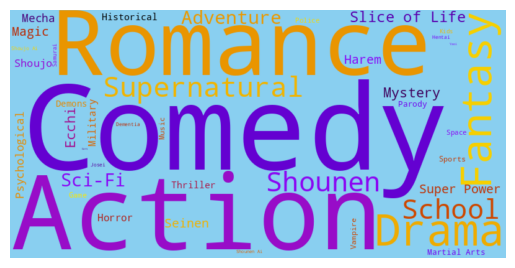

In [130]:
# reference : https://www.kaggle.com/indralin/try-content-based-and-collaborative-filtering

nonull_anime=merged_data.copy()
nonull_anime.dropna(inplace=True)
from collections import defaultdict

all_genres = defaultdict(int)

for genres in nonull_anime['genre']:
    for genre in genres.split(','):
        all_genres[genre.strip()] += 1
        
from wordcloud import WordCloud

genres_cloud = WordCloud(width=800, height=400, background_color='#89CFF0', colormap='gnuplot').generate_from_frequencies(all_genres)
plt.imshow(genres_cloud, interpolation='bilinear')
plt.axis('off')

In [131]:
d1=pd.DataFrame(list(dict(all_genres).keys()),columns=['Genre'])
d2=pd.DataFrame(list(dict(all_genres).values()),columns=['count'])

In [132]:
all_genres1=pd.concat(objs=(d1,d2),axis=1)
all_genres1.head()

,Genre,count
0,Drama,1727681
1,Romance,2031672
2,School,1540797
3,Supernatural,1612455
4,Action,2663837


<Axes: xlabel='count', ylabel='Genre'>

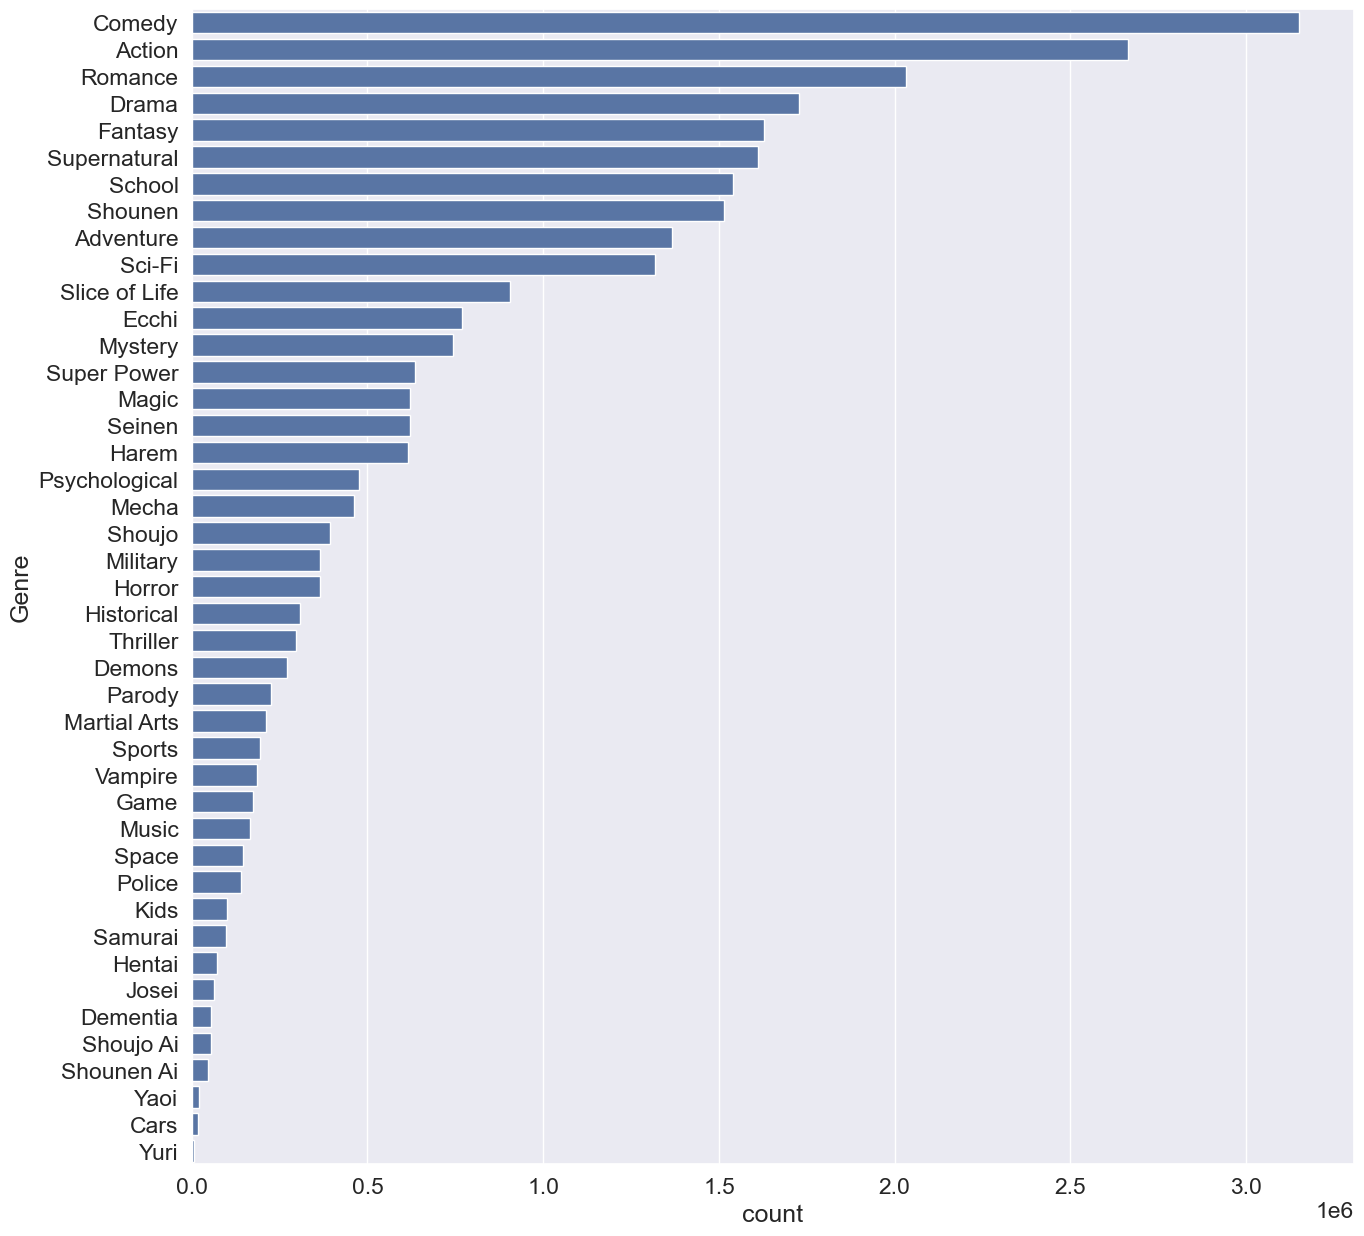

In [133]:
all_genres1=all_genres1.sort_values(by='count',ascending=False)
plt.figure(figsize=(15,15))
sns.barplot(x=all_genres1['count'], y=all_genres1['Genre'])

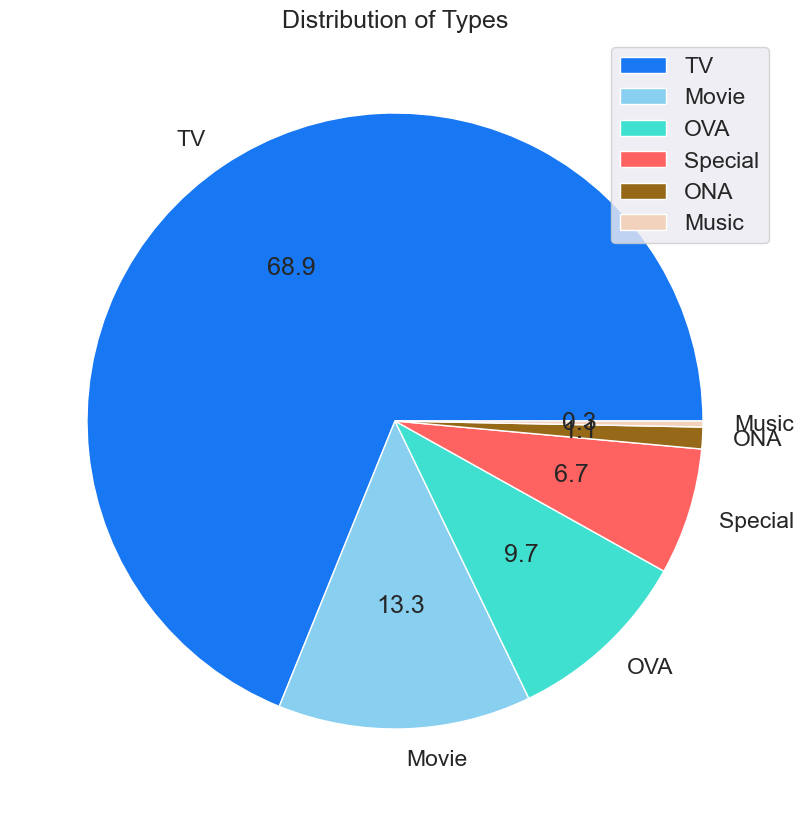

In [134]:
labels = merged_data['type'].value_counts().index
values = merged_data['type'].value_counts().values
plt.figure(figsize=(15,10))
plt.pie(x=values,labels=labels,autopct='%.1f',colors=['#1877F2','#89CFF0','#40E0D0','#FF6361','#966919','#F2D2BD'])
plt.legend()
plt.title('Distribution of Types')
plt.show()

C:\Users\manur\AppData\Local\Temp\ipykernel_10268\3794880116.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x="anime_title", y="user_rating", data=top10_animerating, palette="Dark2")
C:\Users\manur\AppData\Local\Temp\ipykernel_10268\3794880116.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=40, ha="right")


Text(0, 0.5, 'User Rating count')

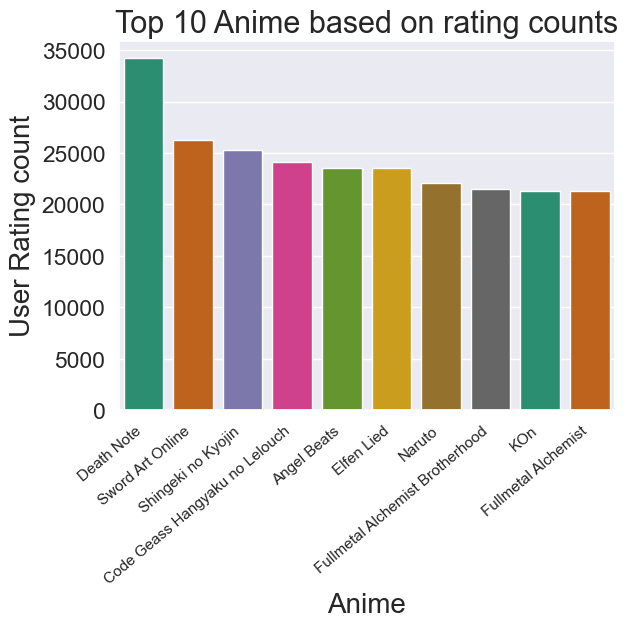

In [135]:
# Creating a dataframe for rating counts
combine_anime_rating = merged_data.dropna(axis = 0, subset = ['anime_title'])
anime_ratingCount = (combine_anime_rating.
     groupby(by = ['anime_title'])['user_rating'].
     count().
     reset_index().rename(columns = {'rating': 'totalRatingCount'})
    [['anime_title', 'user_rating']]
    )

# Plotting the bar plot for top 10 anime as per rating 
top10_animerating=anime_ratingCount[['anime_title', 'user_rating']].sort_values(by = 'user_rating',ascending = False).head(10)
ax=sns.barplot(x="anime_title", y="user_rating", data=top10_animerating, palette="Dark2")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=40, ha="right")
ax.set_title('Top 10 Anime based on rating counts',fontsize = 22)
ax.set_xlabel('Anime',fontsize = 20) 
ax.set_ylabel('User Rating count', fontsize = 20)


In [136]:
## Which anime has the highest ratings

high_rated_anime = merged_data[['anime_title', 'user_rating', 'members', 'type']].sort_values(by='user_rating', ascending=False).query('members>500000').drop_duplicates(subset=['anime_title'])[:5]
high_rated_anime

,anime_title,user_rating,members,type
1961,Fullmetal Alchemist Brotherhood,10,793665,TV
24652,SteinsGate,10,673572,TV
78317,Code Geass Hangyaku no Lelouch R2,10,572888,TV
138588,Code Geass Hangyaku no Lelouch,10,715151,TV
4089930,Highschool of the Dead,10,535892,TV


In [137]:
## Highest rated anime movies

High_rated_movies = merged_data[merged_data['type'] == 'Movie'][['anime_title', 'user_rating', 'members', 'type']].sort_values(by='user_rating', ascending=False).query('members>200000').drop_duplicates(subset=['anime_title'])[:5]
High_rated_movies

,anime_title,user_rating,members,type
19,Kimi no Na wa,10,200630,Movie
102753,Sen to Chihiro no Kamikakushi,10,466254,Movie
1724116,Byousoku 5 Centimeter,10,324035,Movie
131961,Ookami Kodomo no Ame to Yuki,10,226193,Movie
196599,Mononoke Hime,10,339556,Movie


### Correlation

In [138]:
merged_data['user_rating'] = merged_data['user_rating'].astype(int)
corr_matrix = merged_data.corr(numeric_only=True)
corr_matrix

,anime_id,episodes,avg_rating,members,user_id,user_rating
anime_id,1.000000,-0.157043,-0.025331,0.003212,-0.031083,-0.013228
episodes,-0.157043,1.000000,0.159810,0.256167,-0.001170,0.068715
avg_rating,-0.025331,0.159810,1.000000,0.541075,-0.007909,0.410680
members,0.003212,0.256167,0.541075,1.000000,-0.015407,0.232404
user_id,-0.031083,-0.001170,-0.007909,-0.015407,1.000000,0.001878
user_rating,-0.013228,0.068715,0.410680,0.232404,0.001878,1.000000


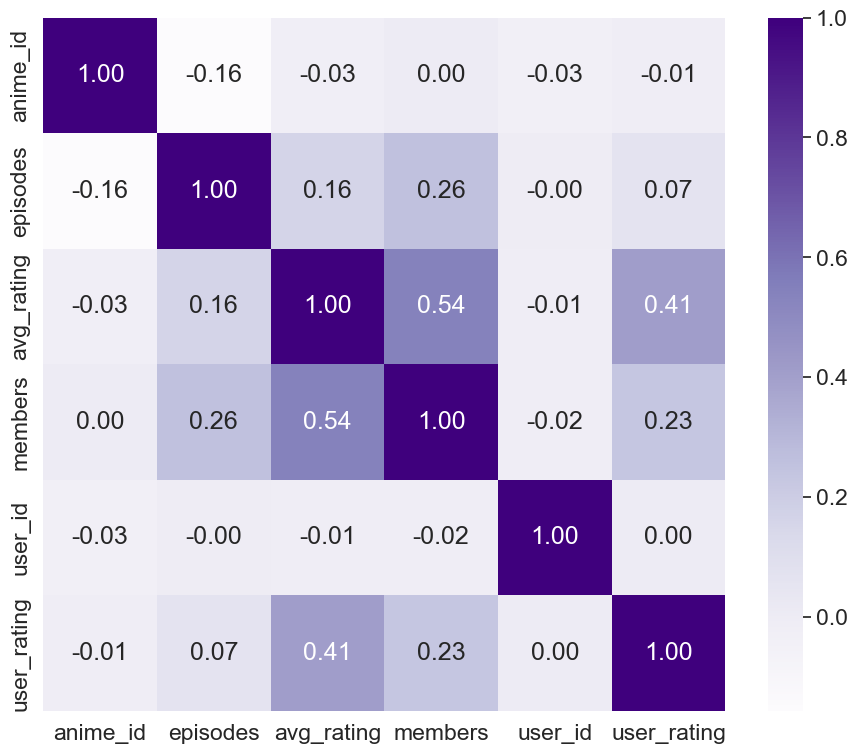

In [139]:
plt.figure(figsize=(11,9))
sns.heatmap(corr_matrix, cmap='Purples', annot=True, fmt=".2f")
sns.set(font_scale=1.5)

## Recommendation system

### Content-Based

In [140]:
anime_data['name'] = anime_data['name'].str.lower()

In [141]:
from sklearn.feature_extraction.text import TfidfVectorizer

genres_str = anime_data['genre'].str.split(',').astype(str)

tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 4), min_df=0.0)
tfidf_matrix = tfidf.fit_transform(genres_str)

tfidf_matrix.shape
# tfidf.get_feature_names()
(12017, 5569)
from sklearn.metrics.pairwise import linear_kernel

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
indices = pd.Series(anime_data.index, index=anime_data['name'].str.lower())


In [142]:
def genre_recommendations(title, highest_rating=False, similarity=False):
    title = title.lower().strip()
    if title not in indices:
        return f"Anime '{title}' not found in metadata."
        
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
        
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    
    anime_indices = [i[0] for i in sim_scores]
    
    if highest_rating == False:
        if similarity == False:
            return pd.DataFrame({'Anime name': anime_data['name'].iloc[anime_indices].values,
                                 'Type': anime_data['type'].iloc[anime_indices].values})
        elif similarity == True:
            similarity_ = [i[1] for i in sim_scores]
            return pd.DataFrame({'Anime name': anime_data['name'].iloc[anime_indices].values,
                                 'Similarity': similarity_,
                                 'Type': anime_data['type'].iloc[anime_indices].values})
    elif highest_rating == True:
        if similarity == False:
            result_df = pd.DataFrame({'Anime name': anime_data['name'].iloc[anime_indices].values,
                                 'Type': anime_data['type'].iloc[anime_indices].values,
                                 'Rating': anime_data['rating'].iloc[anime_indices].values})
            return result_df.sort_values('Rating', ascending=False)
        elif similarity == True:
            similarity_ = [i[1] for i in sim_scores]
            result_df = pd.DataFrame({'Anime name': anime_data['name'].iloc[anime_indices].values,
                                 'Similarity': similarity_,
                                 'Type': anime_data['type'].iloc[anime_indices].values,
                                 'Rating': anime_data['rating'].iloc[anime_indices].values})
            return result_df.sort_values('Rating', ascending=False)


In [143]:
Ani_name = input("Enter the name of the anime: ")
genre_recommendations(Ani_name, highest_rating=True, similarity=True)

,Anime name,Similarity,Type,Rating
1,hakaba kitarou,0.401378,TV,7.01
7,onitensei,0.246008,OVA,6.44
0,teizokurei daydream,0.445939,OVA,6.40
8,tokumu sousakan rei amp fuko,0.246008,OVA,6.37
4,chuumon no ooi ryouriten 1991,0.261274,Movie,6.31
9,mouryou no nie,0.246008,OVA,6.30
5,chuumon no ooi ryouriten,0.261274,Movie,6.18
6,chuumon no ooi ryouriten 1993,0.261274,Movie,5.83
2,fujiko fujio a no mumako,0.401378,OVA,5.35
3,idol fight suchiepai 2,0.361528,OVA,4.48


## Collaborative Filtering (TruncatedSVD Matrix Factorization)

This model uses **Matrix Factorization (TruncatedSVD)** on the user interactions (`rating.csv`) to learn dense latent embeddings for each anime, and recommends similar anime based on the cosine similarity of these user-preference embeddings.

In [144]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

print("Preparing data for TruncatedSVD...")

# Map user_id and anime_id to contiguous indices
user_u = list(sorted(rating_data.user_id.unique()))
item_u = list(sorted(rating_data.anime_id.unique()))

user_to_idx = {user: idx for idx, user in enumerate(user_u)}
item_to_idx = {item: idx for idx, item in enumerate(item_u)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}

user_idx = rating_data['user_id'].map(user_to_idx).values
item_idx = rating_data['anime_id'].map(item_to_idx).values
rating_values = rating_data['rating'].values

# Create sparse interaction matrix (Users as rows, Anime as columns)
sparse_matrix = csr_matrix((rating_values, (user_idx, item_idx)), shape=(len(user_u), len(item_u)))

# Run TruncatedSVD to get anime embeddings (transpose to get anime as rows)
print("Fitting TruncatedSVD model...")
svd = TruncatedSVD(n_components=50, random_state=42)
anime_embeddings = svd.fit_transform(sparse_matrix.T)

# Compute cosine similarity matrix between anime
cf_cosine_sim = cosine_similarity(anime_embeddings)
print("CF Similarity Matrix shape:", cf_cosine_sim.shape)

# Prepare lookup helper dictionaries
name_to_anime_id = pd.Series(anime_data.anime_id.values, index=anime_data['name'].str.lower()).to_dict()
anime_id_to_name = pd.Series(anime_data['name'].values, index=anime_data.anime_id.values).to_dict()

def cf_recommendations(title, limit=10):
    title_clean = title.lower().strip()
    if title_clean not in name_to_anime_id:
        return f"Anime '{title}' not found in metadata."
    
    anime_id = name_to_anime_id[title_clean]
    if anime_id not in item_to_idx:
        return f"Anime '{title}' has no rating interactions for Collaborative Filtering."
        
    idx = item_to_idx[anime_id]
    sim_scores = list(enumerate(cf_cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:limit+1]
    
    rec_names = []
    rec_sims = []
    rec_types = []
    rec_ratings = []
    
    for i, score in sim_scores:
        rec_anime_id = idx_to_item[i]
        # Lookup in metadata
        metadata = anime_data[anime_data['anime_id'] == rec_anime_id]
        if not metadata.empty:
            rec_names.append(metadata['name'].values[0])
            rec_types.append(metadata['type'].values[0])
            rec_ratings.append(metadata['rating'].values[0])
        else:
            rec_names.append(anime_id_to_name.get(rec_anime_id, f"ID: {rec_anime_id}"))
            rec_types.append("Unknown")
            rec_ratings.append(None)
        rec_sims.append(score)
        
    return pd.DataFrame({
        'Anime name': rec_names,
        'Similarity': rec_sims,
        'Type': rec_types,
        'Rating': rec_ratings
    })

Preparing data for TruncatedSVD...
Fitting TruncatedSVD model...
CF Similarity Matrix shape: (9927, 9927)


In [145]:
# Test the Collaborative Filtering recommendations
cf_recommendations("bleach", limit=10)

,Anime name,Similarity,Type,Rating
0,bleach movie 4 jigokuhen,0.847459,Movie,7.75
1,fairy tail,0.808102,TV,8.22
2,bleach movie 3 fade to black kimi no na wo yobu,0.805439,Movie,7.66
3,beelzebub,0.776264,TV,8.04
4,bleach movie 2 the diamonddust rebellion mou ...,0.771830,Movie,7.60
5,bleach movie 1 memories of nobody,0.764911,Movie,7.58
6,katekyo hitman reborn,0.764467,TV,8.37
7,ao no exorcist,0.749362,TV,7.92
8,bleach memories in the rain,0.714315,Special,7.21
9,bleach the sealed sword frenzy,0.697087,Special,7.05


## Hybrid (XGBoost Leaf Embeddings) Recommendation

This model trains an **XGBoost Regressor** to predict rating based on metadata (Genres via TF-IDF, Type, and Member count). We then extract the leaf indices for each anime across all trees as a dense non-linear embedding, and compute cosine similarity on these leaf embeddings.

In [146]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

print("Preparing features for XGBoost...")

# Fill NAs
anime_data['genre'] = anime_data['genre'].fillna('')
anime_data['type'] = anime_data['type'].fillna('Unknown')
anime_data['rating'] = anime_data['rating'].fillna(anime_data['rating'].mean())
anime_data['members'] = anime_data['members'].fillna(0)

# TF-IDF on Genres (max 50 features)
xgb_tfidf = TfidfVectorizer(max_features=50)
genre_features = xgb_tfidf.fit_transform(anime_data['genre']).toarray()

# Label Encode Type
le = LabelEncoder()
type_encoded = le.fit_transform(anime_data['type'])

# Create feature matrix and target values
X_xgb = np.column_stack((genre_features, type_encoded, anime_data['members'].values))
y_xgb = anime_data['rating'].values

print("Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_xgb, y_xgb)

print("Extracting Leaf Embeddings...")
xgb_embeddings = xgb_model.apply(X_xgb)

print("Computing hybrid cosine similarity...")
hybrid_cosine_sim = cosine_similarity(xgb_embeddings)
print("Hybrid Similarity Matrix shape:", hybrid_cosine_sim.shape)

anime_indices = pd.Series(anime_data.index, index=anime_data['name'].str.lower())

def hybrid_recommendations(title, limit=10):
    title_clean = title.lower().strip()
    if title_clean not in anime_indices:
        return f"Anime '{title}' not found in metadata."
        
    idx = anime_indices[title_clean]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
        
    sim_scores = list(enumerate(hybrid_cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:limit+1]
    
    rec_indices = [i[0] for i in sim_scores]
    rec_sims = [i[1] for i in sim_scores]
    
    rec_df = anime_data.iloc[rec_indices].copy()
    rec_df['Similarity'] = rec_sims
    
    return rec_df[['name', 'Similarity', 'type', 'rating']].rename(columns={
        'name': 'Anime name',
        'type': 'Type',
        'rating': 'Rating'
    })

Preparing features for XGBoost...
Training XGBoost Regressor...
Extracting Leaf Embeddings...
Computing hybrid cosine similarity...
Hybrid Similarity Matrix shape: (12017, 12017)


In [147]:
# Test the Hybrid recommendations
hybrid_recommendations("bleach", limit=10)

,Anime name,Similarity,Type,Rating
288,fairy tail,0.999627,TV,8.22
440,soul eater,0.999626,TV,8.08
178,boku no hero academia,0.999217,TV,8.36
339,noragami,0.999215,TV,8.17
175,katekyo hitman reborn,0.999187,TV,8.37
859,tokyo ravens,0.999162,TV,7.80
184,bakuman,0.999152,TV,8.35
1083,inu x boku ss,0.999139,TV,7.69
464,school rumble,0.999119,TV,8.06
281,kill la kill,0.999025,TV,8.23
